In [10]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import math

In [11]:
image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}

image_file_lst = {}

for fol_name in ['processed', 'cropped']:

    folder_path = Path('../data/' + fol_name)
    image_file_lst[fol_name] = [
        file for file in folder_path.iterdir() 
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

print(image_file_lst)

{'processed': [WindowsPath('../data/processed/img1.jpg'), WindowsPath('../data/processed/img2.jpg'), WindowsPath('../data/processed/img3.jpg'), WindowsPath('../data/processed/img4.jpg'), WindowsPath('../data/processed/img5.jpg'), WindowsPath('../data/processed/img6.jpg'), WindowsPath('../data/processed/img7.jpg'), WindowsPath('../data/processed/img8.jpg')], 'cropped': [WindowsPath('../data/cropped/img1.jpg'), WindowsPath('../data/cropped/img2.jpg'), WindowsPath('../data/cropped/img3.jpg'), WindowsPath('../data/cropped/img4.jpg'), WindowsPath('../data/cropped/img5.jpg'), WindowsPath('../data/cropped/img6.jpg'), WindowsPath('../data/cropped/img7.jpg'), WindowsPath('../data/cropped/img8.jpg')]}


In [12]:
def detect_edges(img_gray, low_thresh=60, high_thresh=150):
    edges = cv2.Canny(img_gray, low_thresh, high_thresh)
    return edges

In [13]:
def get_lines (edges_img, threshold=80, minLineLength=110, maxLineGap=80):
    return cv2.HoughLinesP(
        edges_img, 
        1, 
        np.pi/180, 
        threshold=threshold, 
        minLineLength=minLineLength, 
        maxLineGap=maxLineGap
    )

In [14]:
def filter_lines_by_length(lines, min_len=60, max_len=600):
    """
    Lọc đường thẳng dựa trên độ dài (Euclidean distance).
    Loại bỏ các đường quá ngắn (nhiễu) hoặc quá dài (vết nứt ngang đường).
    """
    if lines is None:
        return None

    filtered_lines = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        if min_len <= length <= max_len:
            filtered_lines.append(line)
            
    return filtered_lines

In [15]:
def apply_roi_mask(img, upper_limit=0.4):
    """
    Che đi phần trên của ảnh.
    upper_limit: Tỷ lệ phần trên muốn che (0.5 = 50%).
    """
    mask = np.zeros_like(img)
    height, width = img.shape[:2]
    
    start_y = int(height * upper_limit)
    
    polygons = np.array([
        [(0, height), (width, height), (width, start_y), (0, start_y)]
    ])
    
    if len(img.shape) > 2: # Ảnh màu
        cv2.fillPoly(mask, polygons, (255, 255, 255))
    else: # Ảnh xám/biên
        cv2.fillPoly(mask, polygons, 255)
        
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image

In [16]:
def filter_lines_by_angle(lines, min_angle=5, max_angle=80):
    """
    Lọc các đường thẳng dựa trên góc nghiêng (độ).
    min_angle, max_angle: Khoảng góc muốn giữ lại (ví dụ 20 đến 80 độ).
    """
    filtered_lines = []
    
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            
            angle_rad = math.atan2(abs(y2 - y1), abs(x2 - x1))
            angle_deg = math.degrees(angle_rad)
            
            if min_angle <= angle_deg <= max_angle:
                filtered_lines.append(line)
                
    return filtered_lines

In [17]:
def detect_and_draw_lines(edges_img, img_path):
    """
    Tìm đường thẳng và vẽ đè lên ảnh gốc. Trả về bức ảnh đã vẽ.
    """
    img_with_lines = cv2.imread(img_path)
    if img_with_lines is None:
        print(f"Lỗi: Không đọc được ảnh tại {img_path}")
        return None

    img = apply_roi_mask(edges_img.copy())

    lines = get_lines(img)

    lines_step1 = filter_lines_by_length(lines)

    final_lines = filter_lines_by_angle(lines_step1)
    
    if final_lines is not None:
        for line in final_lines:
            x1, y1, x2, y2 = line[0]
            # Màu Đỏ trong OpenCV là (0, 0, 255) - hệ BGR
            cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
    return img_with_lines

Đã lưu xong: img1.jpg


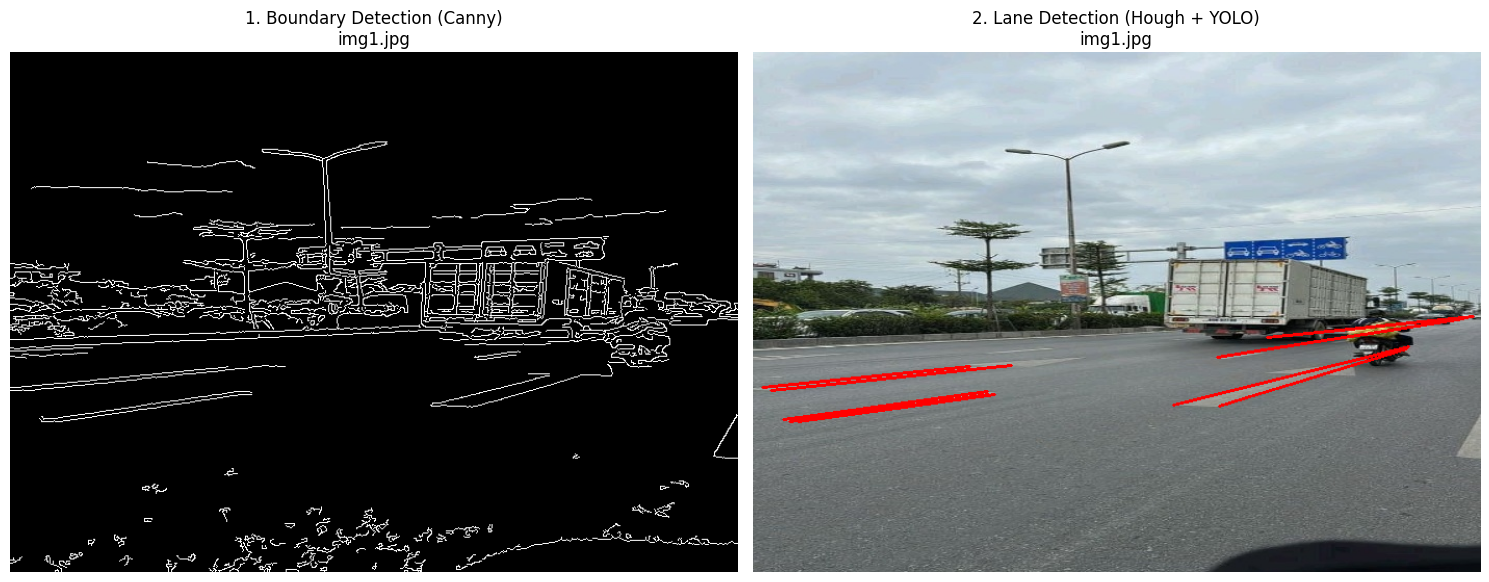

Đã lưu xong: img2.jpg


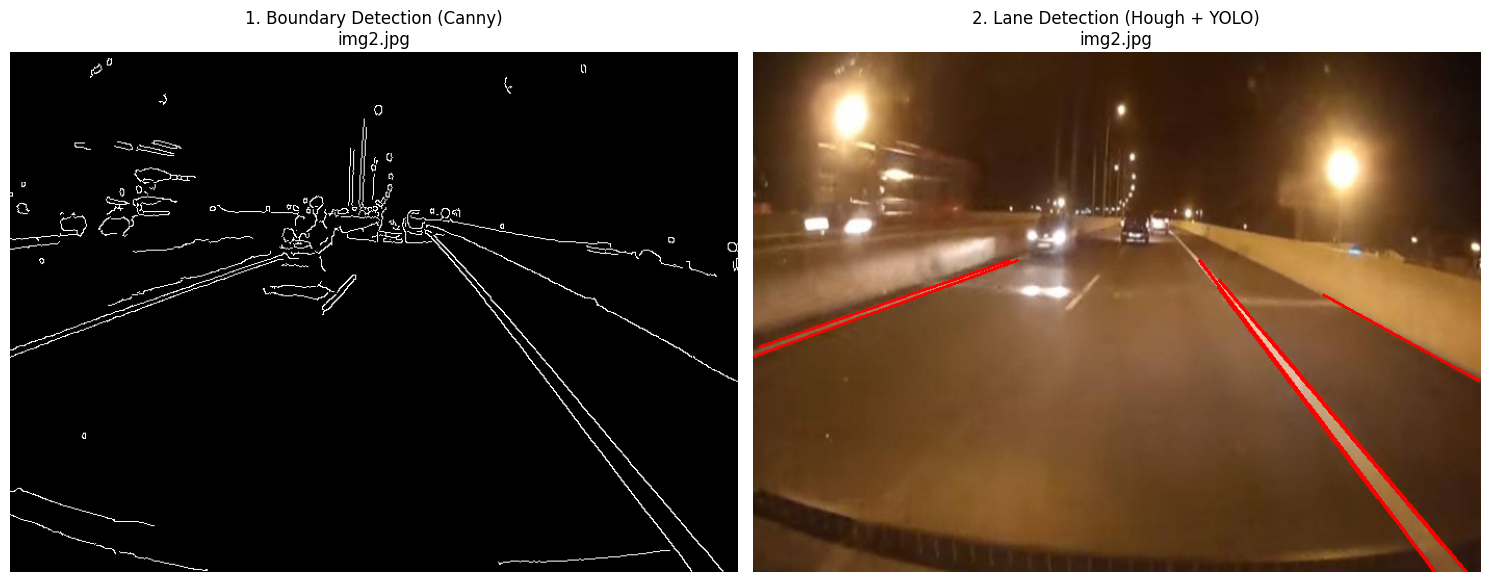

Đã lưu xong: img3.jpg


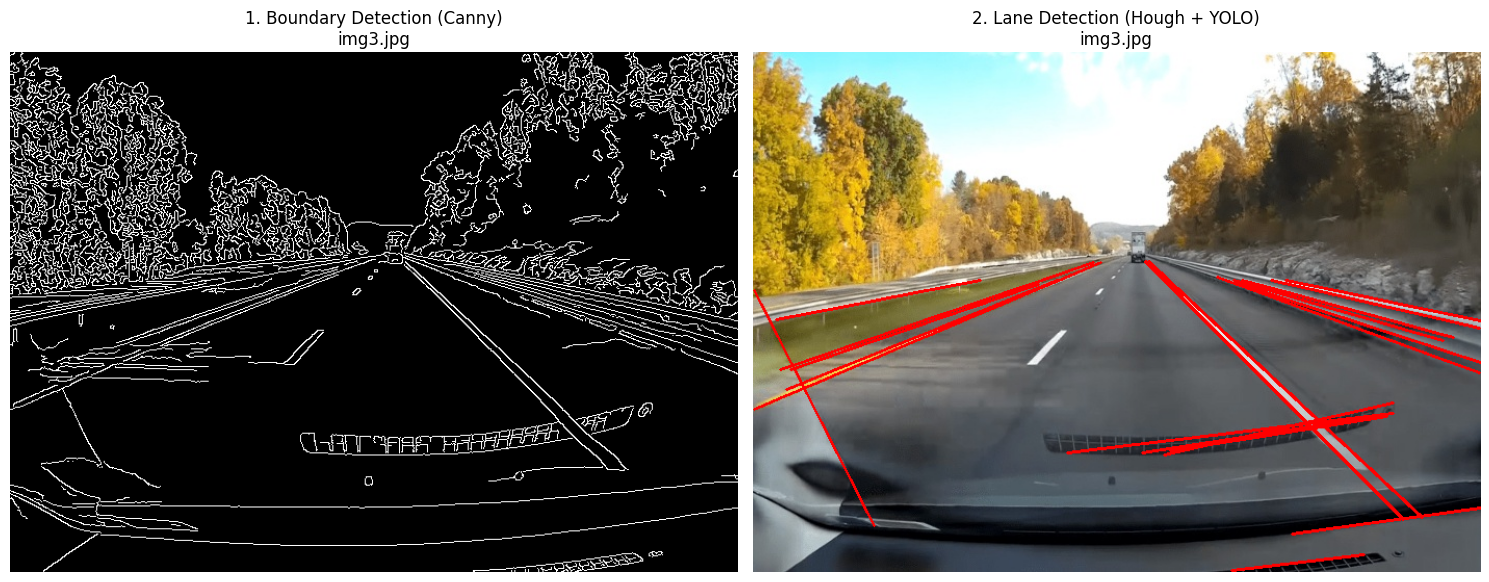

Đã lưu xong: img4.jpg


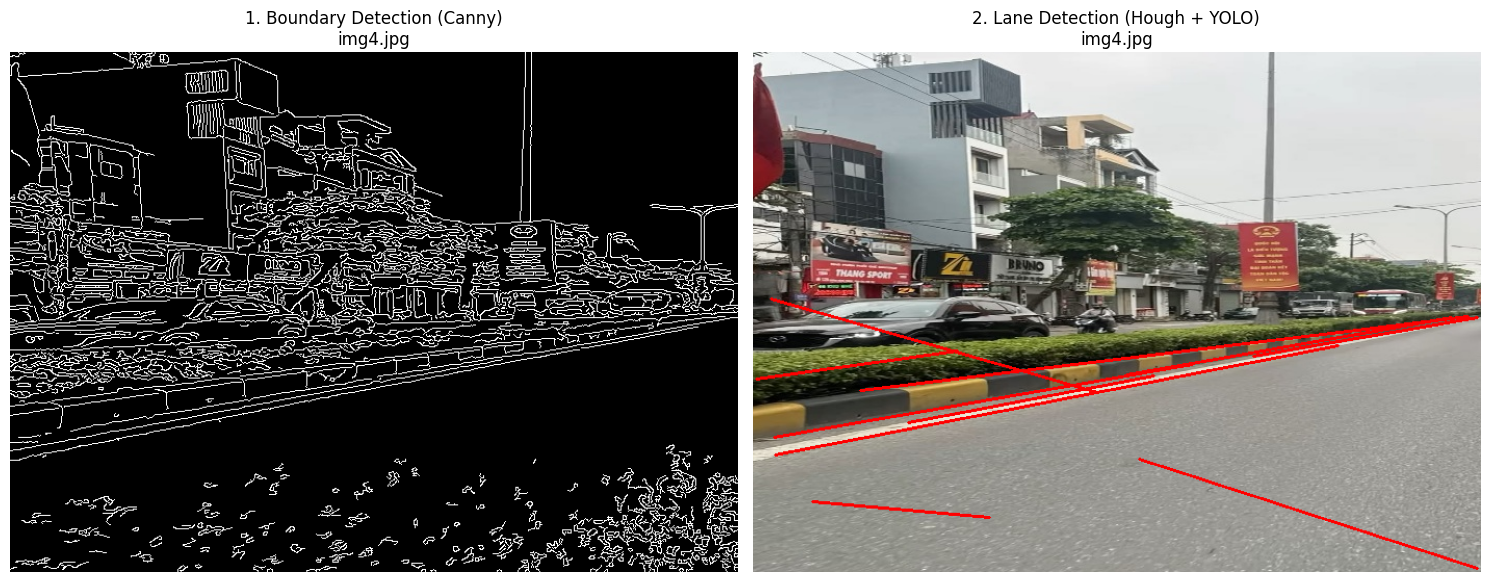

Đã lưu xong: img5.jpg


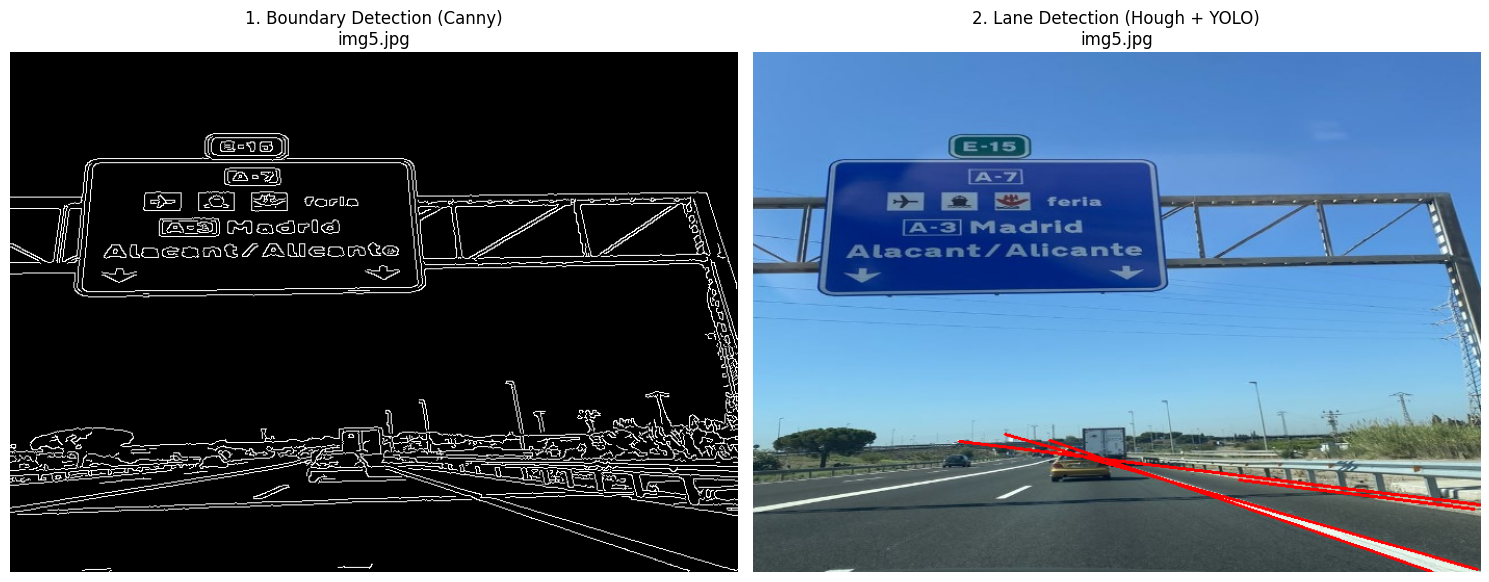

Đã lưu xong: img6.jpg


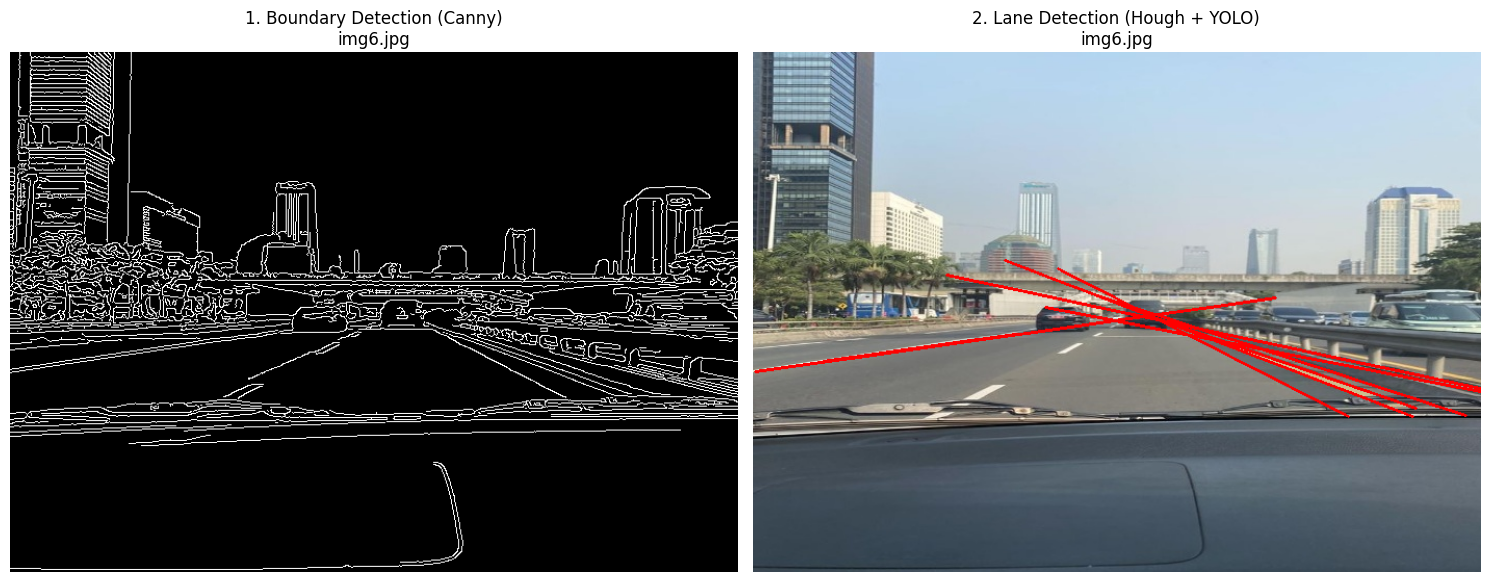

Đã lưu xong: img7.jpg


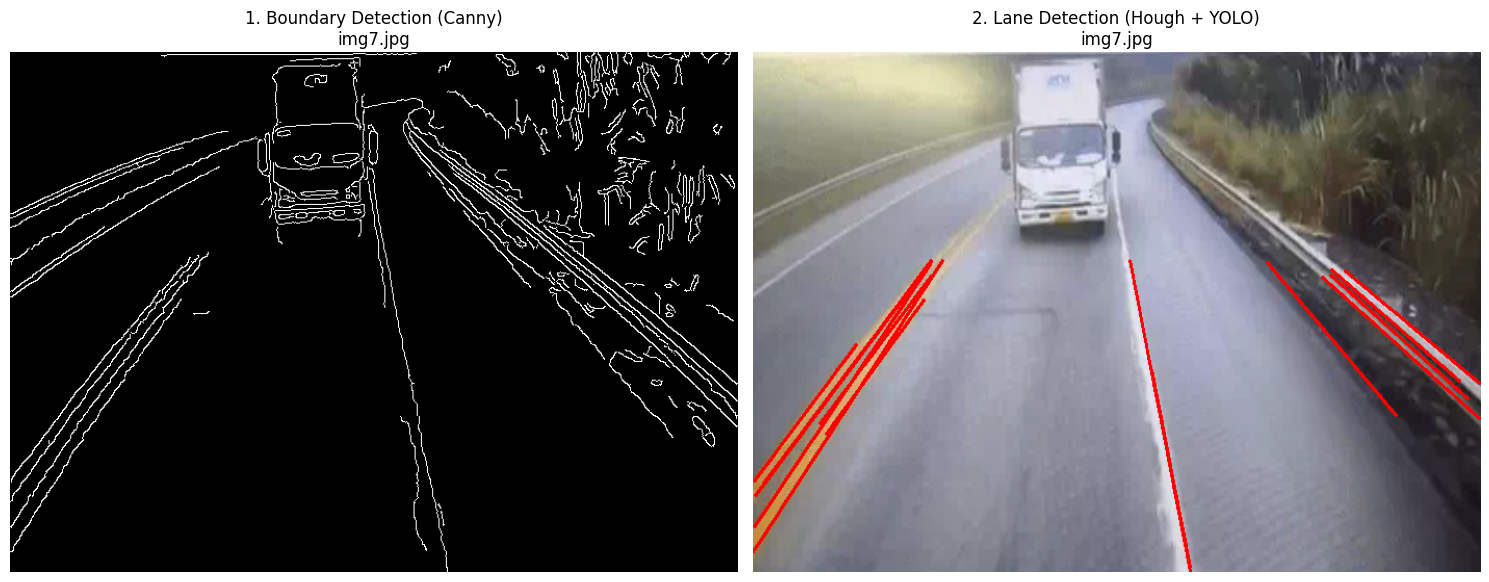

Đã lưu xong: img8.jpg


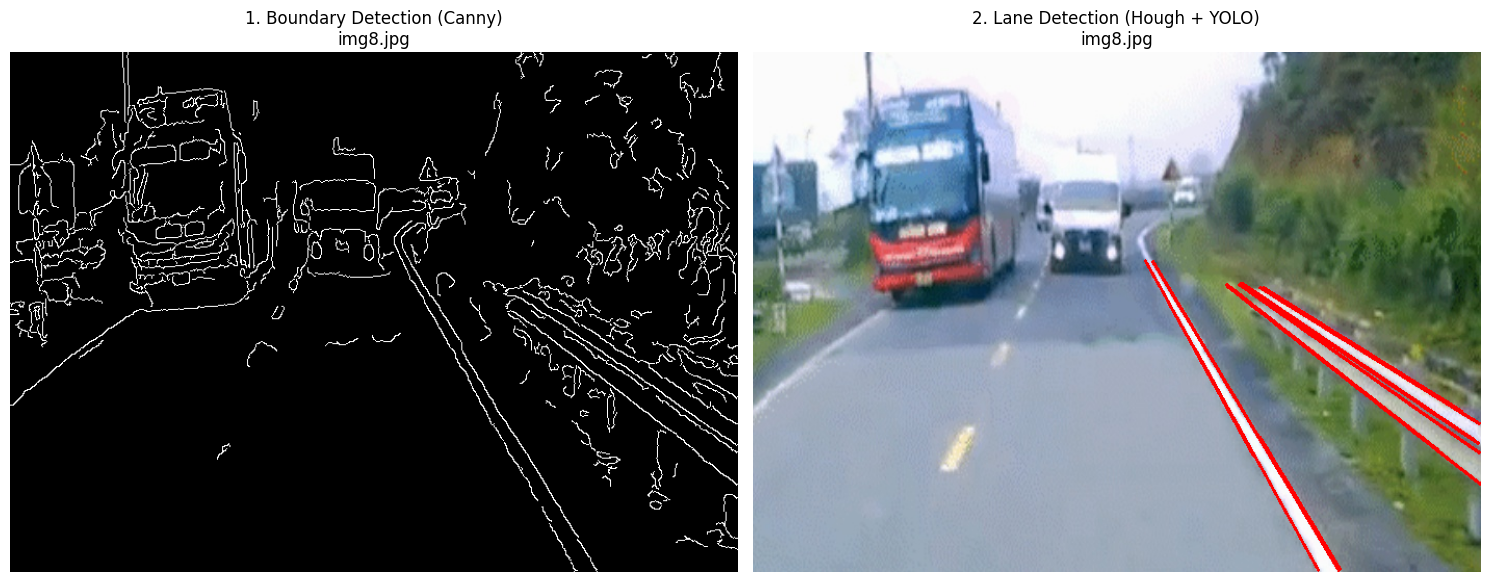

In [18]:
path_boundary = Path('../results/Images/BoundaryDetection')
path_hough = Path('../results/Images/HoughLines')

path_boundary.mkdir(parents=True, exist_ok=True)
path_hough.mkdir(parents=True, exist_ok=True)

for p_path, c_path in zip(image_file_lst['processed'], image_file_lst['cropped']):
    
    processed_img = cv2.imread(str(p_path))
    if processed_img is None: continue
    
    edges = detect_edges(processed_img)
    
    final_img = detect_and_draw_lines(edges, str(c_path))
    
    if final_img is None: continue

    if final_img is not None:
        file_name = p_path.name
        
        save_path_edges = str(path_boundary / file_name)
        cv2.imwrite(save_path_edges, edges)
        
        save_path_hough = str(path_hough / file_name)
        cv2.imwrite(save_path_hough, final_img)
        
        print(f"Đã lưu xong: {file_name}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

    ax1.imshow(edges, cmap='gray')
    ax1.set_title(f"1. Boundary Detection (Canny)\n{p_path.name}")
    ax1.axis('off')

    final_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
    ax2.imshow(final_rgb)
    ax2.set_title(f"2. Lane Detection (Hough + YOLO)\n{c_path.name}")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()